In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
plt.style.use('seaborn-v0_8-white')

In [168]:
df = pd.read_csv('AirPassNew.csv')

In [169]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [170]:
#Новые столбцы
df['satisfaction_0_1'] = df['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)

def age_category(age):
    if age <= 17:
        return '0-17'
    elif age <= 29:
        return '18-29'
    elif age <= 44:
        return '30-44'
    elif age <= 59:
        return '45-59'
    else:
        return '60+'

df['age_category'] = df['Age'].apply(age_category)

In [171]:
df['age_category'].value_counts().sort_index()

age_category
0-17      796
18-29    2313
30-44    3284
45-59    3004
60+       969
Name: count, dtype: int64

# №1 Bar для общей удовлетворенности

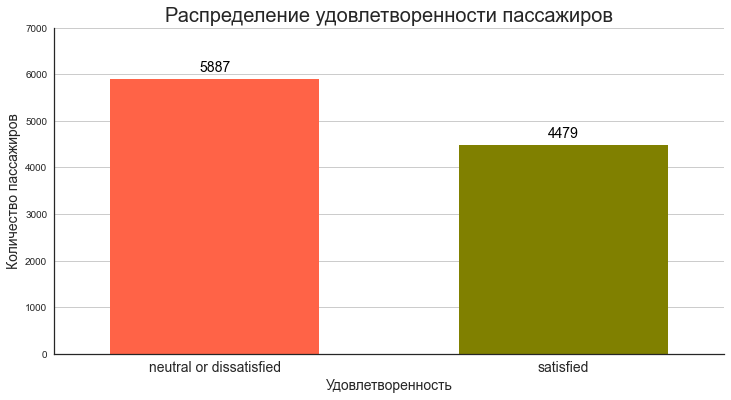

In [172]:
counts = df['satisfaction'].value_counts()

plt.figure(figsize=(12,6))
plt.bar(counts.index, counts.values, width=0.6, color=['tomato', 'olive'])
plt.title('Распределение удовлетворенности пассажиров', fontsize=20)
plt.xlabel('Удовлетворенность', fontsize=14)
plt.ylabel('Количество пассажиров', fontsize=14)
plt.ylim(0, 7000)
plt.xticks(fontsize=14)
plt.text(0, counts.values[0]+100, str(counts.values[0]), ha='center', va='bottom', fontsize=14, color='black')
plt.text(1, counts.values[1]+100, str(counts.values[1]), ha='center', va='bottom', fontsize=14, color='black')
plt.margins(x=0.1)
plt.grid(True)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False, axis='x')
plt.show()

**Интерпретация:** График показывает распределение довольных (4479) и недовольных/нейтральных (5887) пассажиров. Недовольных/нейтральных пассажиров больше.

# №2 Hist для дальности полета

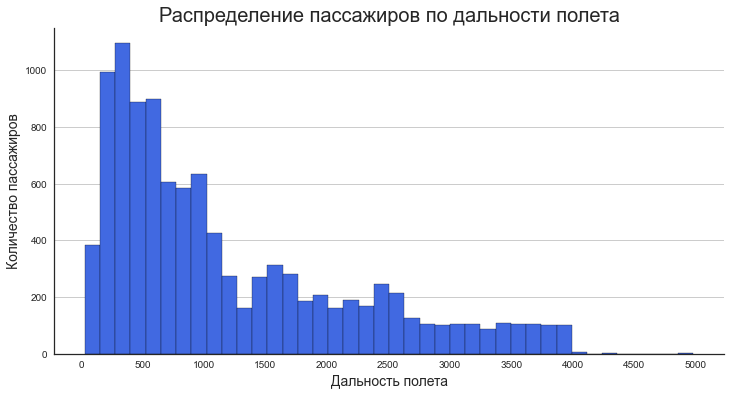

In [173]:
plt.figure(figsize=(12,6))
plt.hist(df['Flight Distance'], bins=40, color='royalblue', edgecolor='black')
plt.title('Распределение пассажиров по дальности полета', fontsize=20)
plt.xlabel('Дальность полета', fontsize=14)
plt.ylabel('Количество пассажиров', fontsize=14)
plt.xticks([i for i in range(0, 5500, 500)])
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y')
plt.show()

**Интерпретация:** График показывает распределение пассажиров по дальности полета. Можно сделать вывод, что большинство полетов до 1000 км.

# №3 Scatter для задержек отправления и прибытия

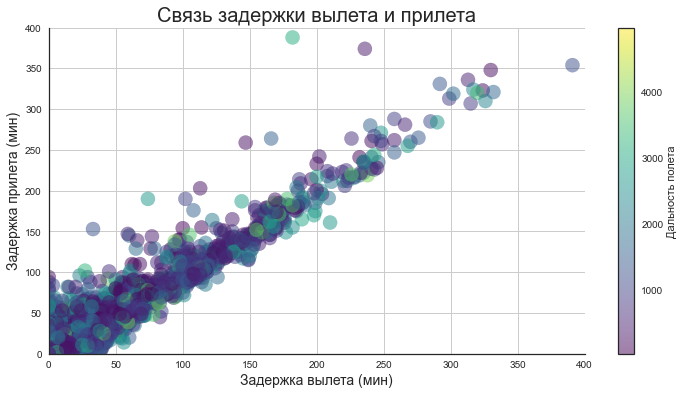

In [174]:
plt.figure(figsize=(12,6))
plt.scatter(df['Departure Delay in Minutes'], 
            df['Arrival Delay in Minutes'], 
            c=df['Flight Distance'], 
            cmap='viridis',
            s=200,
            alpha=0.5)
plt.title('Связь задержки вылета и прилета', fontsize=20)
plt.xlabel('Задержка вылета (мин)', fontsize=14)
plt.ylabel('Задержка прилета (мин)', fontsize=14)
plt.xlim(0, 400)
plt.ylim(0, 400)
plt.colorbar(label='Дальность полета')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(True)
plt.show()

**Интерпретация:** График показывает линейную зависимость между задержкой отправления и прибытия. Экстремальные задержки (более 400 минут) исключены для наглядности. Цвет точек показывает дальность полета.

# №4 Pie для оценок сервисных факторов

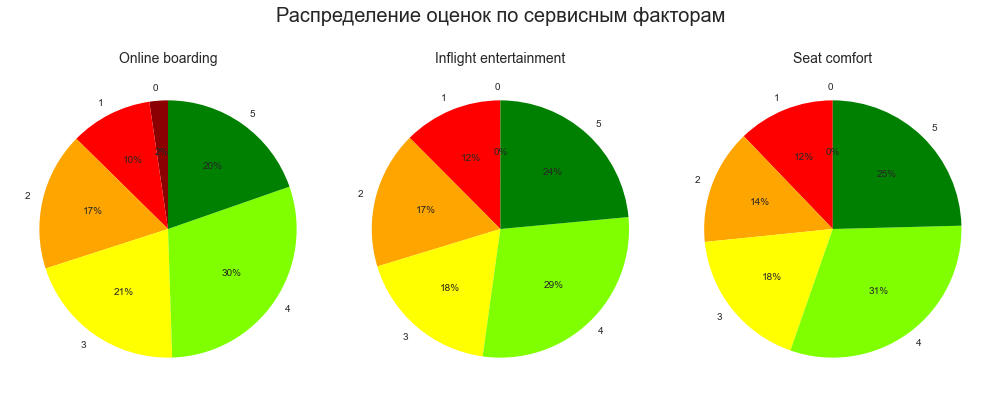

In [175]:
service = ['Online boarding', 'Inflight entertainment', 'Seat comfort']
colors = ['darkred', 'red', 'orange', 'yellow', 'chartreuse', 'green']
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
for i in range(3):
    counts = df[service[i]].value_counts().sort_index()
    ax[i].pie(counts, labels=counts.index, autopct='%1.0f%%', startangle=90, colors=colors)
    ax[i].set_title(service[i], fontsize=14)
plt.suptitle('Распределение оценок по сервисным факторам', fontsize=20)
plt.tight_layout()
plt.show()

**Интерпретация:** График показывает распределение оценок по трем сервисным факторам, которые больше всего влияют на удовлетворенность. Большинство пассажиров оценили ключевые сервисные факторы на 4 или 5, что говорит об их общей удовлетворенности этими аспектами полета.

# №5 Heatmap для средних оценок сервисных факторов

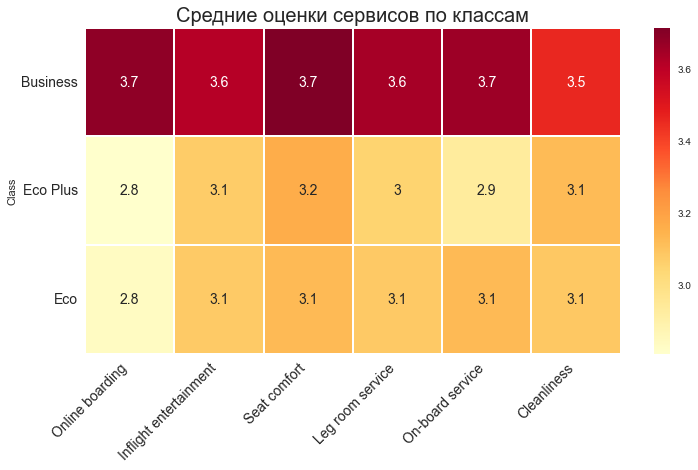

In [176]:
service = ['Online boarding', 'Inflight entertainment', 'Seat comfort', 'Leg room service', 'On-board service', 'Cleanliness']
class_service_means = df.groupby('Class')[service].mean()
class_service_means = class_service_means.loc[['Business', 'Eco Plus', 'Eco']]

plt.figure(figsize=(12,6))
sns.heatmap(class_service_means, annot=True, annot_kws={'size': 14}, cmap='YlOrRd', linewidths=0.1)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=360, fontsize=14)
plt.title('Средние оценки сервисов по классам', fontsize=20)
plt.show()

**Интерпретация:** Тепловая карта показывает, что пассажиры бизнес-класса оценивают все сервисы выше, чем пассажиры эконома. Особенно заметна разница по онлайн-регистрации. Эконом и эконом-плюс имеют примерно одинаковые оценки.

# №6 Boxplot для оценок сервисов среди довольных и недовольных

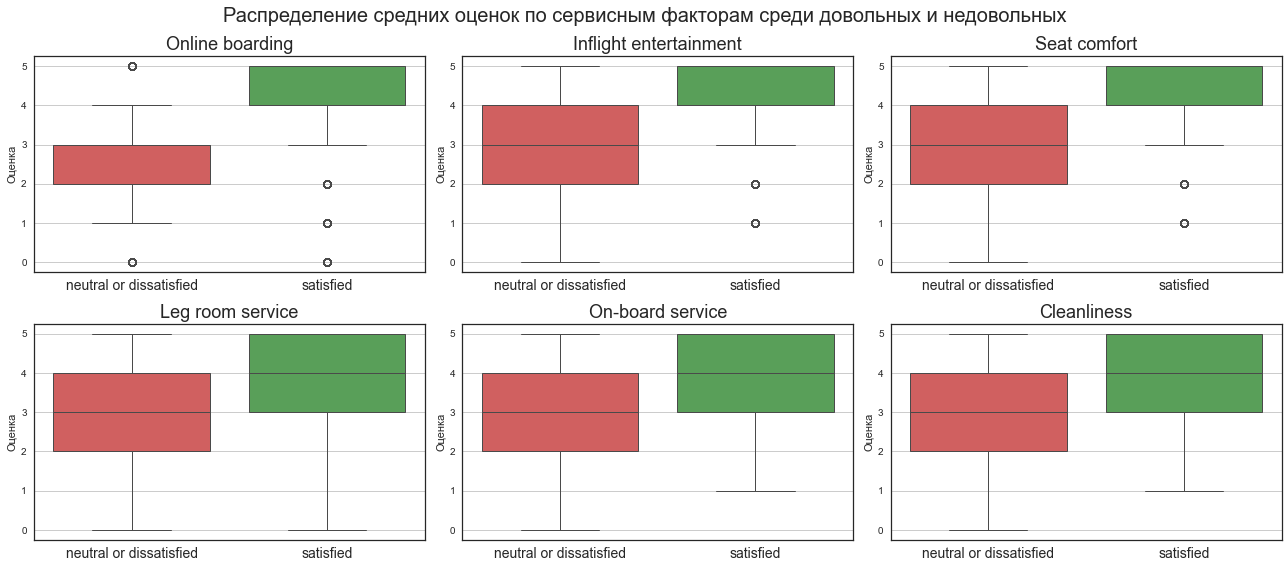

In [177]:
service = ['Online boarding', 'Inflight entertainment', 'Seat comfort', 'Leg room service', 'On-board service', 'Cleanliness']

fig, ax = plt.subplots(2, 3, figsize=(18, 8))
ax_flatt = ax.flatten()
for i in range(6):
    sns.boxplot(data=df, x='satisfaction', y=service[i], ax=ax_flatt[i], hue='satisfaction',
                palette=['#e34d4d', '#4dab4d'], legend=False)
    ax_flatt[i].set_title(service[i], fontsize=18)
    ax_flatt[i].set_xlabel('')
    ax_flatt[i].set_ylabel('Оценка')
    ax_flatt[i].tick_params(axis='x', labelsize=14)
    ax_flatt[i].grid(True, axis='y')
plt.suptitle('Распределение средних оценок по сервисным факторам среди довольных и недовольных', fontsize=20)
plt.tight_layout()
plt.show()

**Интерпретация:** Во всех сервисах довольные пассажиры ставят оценки выше, чем недовольные.

- Онлайн-регистрация - самый важный фактор. Довольные ставят 4-5, недовольные - 2-3. Эти группы почти не пересекаются.

- Развлечения и комфорт сидений - средние по важности. Их оценки пересекаются, но не сильно.

- Место для ног, сервис на борту и чистота - слабее всего разделяют довольных и недовольных. Их оценки заметно пересекаются.

# №7 Hist для распределения возраста по классам обслуживания

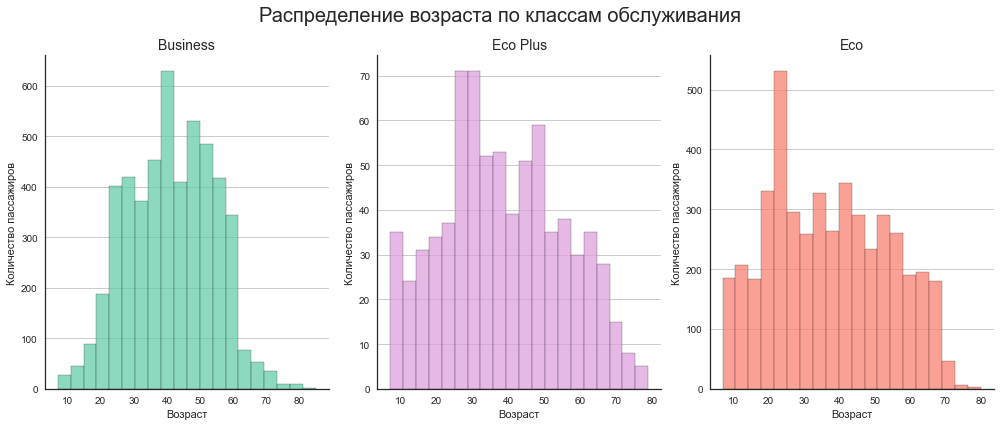

In [178]:
classes = ['Business', 'Eco Plus', 'Eco']
colors = ['mediumaquamarine', 'plum', 'salmon']

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
for i in range(3):
    ax[i].hist(df[df['Class'] == classes[i]]['Age'], bins=20, alpha=0.75, color=colors[i], edgecolor='black')
    ax[i].set_title(classes[i], fontsize=14)
    ax[i].set_xlabel('Возраст')
    ax[i].set_ylabel('Количество пассажиров')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].grid(True, axis='y')
plt.suptitle('Распределение возраста по классам обслуживания', fontsize=20)
plt.tight_layout()
plt.show()

**Интерпретация:** В бизнес-классе чаще летают люди среднего (около 40 лет) и старшего (50-60 лет) возраста. В эконом-классе больше летает молодежь (моложе 30 лет). В классе эконом-плюс пассажиров значительно меньше. Этим классом чаще летают люди тридцати с небольшим лет. 

# №8 Bar для удовлетворенности по возрастным группам

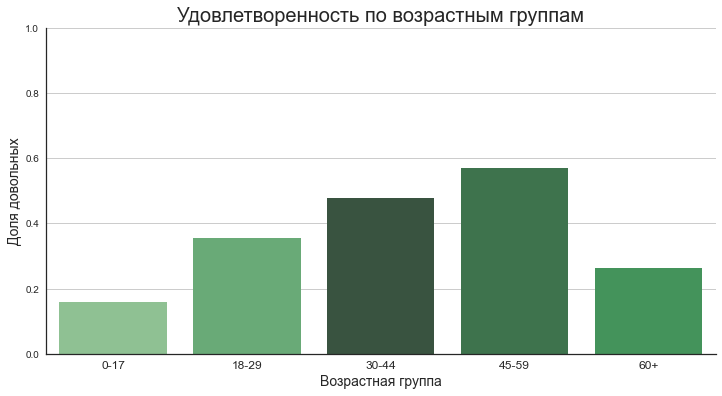

In [179]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='age_category', y='satisfaction_0_1', 
            order = ['0-17', '18-29', '30-44', '45-59', '60+'],
            errorbar=None,
            hue='age_category',
            palette='Greens_d',
            legend=False)
plt.title('Удовлетворенность по возрастным группам', fontsize=20)
plt.xticks(fontsize=12)
plt.xlabel('Возрастная группа', fontsize=14)
plt.ylabel('Доля довольных', fontsize=14)
plt.ylim(0, 1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y')
plt.show()

**Интерпретация:** В группе 45-59 лет больше всего довольных пассажиров. Меньше всего довольных в группе 0-17 лет. С возрастом удовлетворенность возрастает, однако после 60 лет снижается.

# №9 Violin для распределения возраста по классам в разрезе лояльности

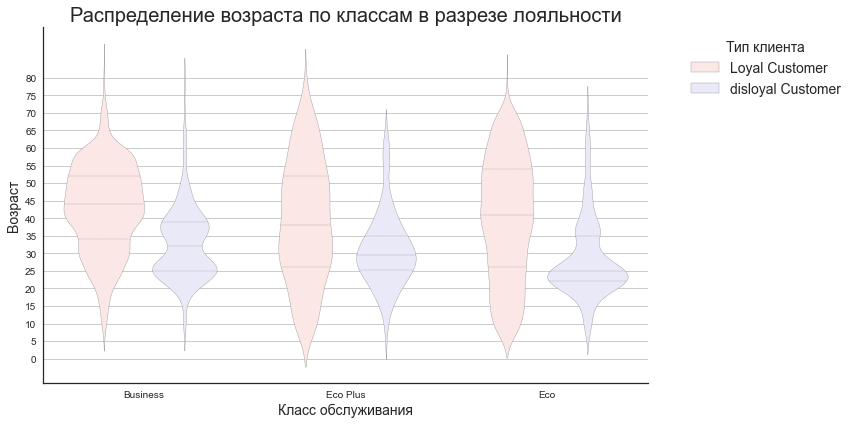

In [180]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Class', order = ['Business', 'Eco Plus', 'Eco'], y='Age', hue='Customer Type', 
               split=False, palette=['mistyrose', 'lavender'], inner='quartile')
plt.title('Распределение возраста по классам в разрезе лояльности', fontsize=20)
plt.xlabel('Класс обслуживания', fontsize=14)
plt.ylabel('Возраст', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Тип клиента', title_fontsize=14, fontsize=14)
plt.yticks([i for i in range(0, 85, 5)])
plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y')
plt.show()

**Интерпретация:** Медианный возраст во всех классах обслуживания выше для группы лояльных пассажиров.  
У нелояльных пассажиров распределение возраста имеет выраженные пики: в бизнес-классе они приходятся на 25 лет и диапазон 35-40 лет, в эконом-плюс - на 25-30 лет, в эконом-классе - на 20-25 лет.
У лояльных пассажиров распределение возраста более равномерное. Исключение - бизнес-класс, где наблюдается небольшой пик в интервале 40-45 лет.

# №10 Boxplot для средней оценки по сервисным факторам

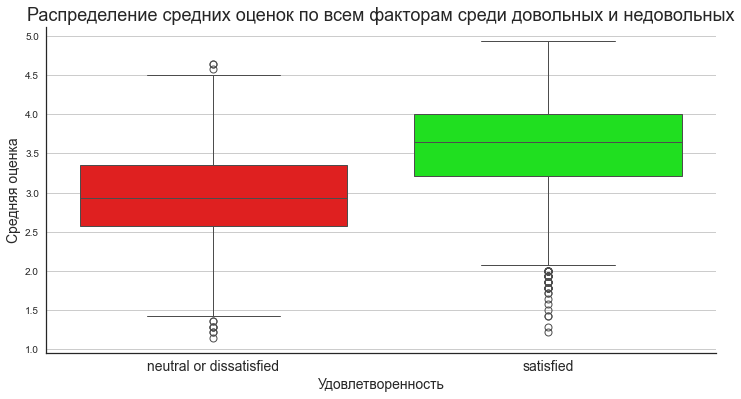

In [181]:
services = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
            'Gate location', 'Food and drink', 'Online boarding', 
            'Seat comfort', 'Inflight entertainment', 'On-board service', 
            'Leg room service', 'Baggage handling', 'Checkin service', 
            'Inflight service', 'Cleanliness'] 
df['avg_service'] = df[services].mean(axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='satisfaction', y='avg_service', hue='satisfaction', palette=['red', 'lime'], legend=False)
plt.title('Распределение средних оценок по всем факторам среди довольных и недовольных', fontsize=18)
plt.xticks(fontsize=14)
plt.xlabel('Удовлетворенность', fontsize=14)
plt.ylabel('Средняя оценка', fontsize=14)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y')
plt.show()

**Интерпретация:** У довольных пассажиров средние оценки по всем сервисным факторам выше, чем у нейтральных/недовольных, и сосредоточены в промежутке от 3,2 до 4. Медиана в этой группе - около 3,6. У недовольных большинство средних оценок лежит в диапазоне 2,5-3,4, медиана - 2,9. В обеих группах встречаются выбросы: у недовольных есть оценки выше 4,5, у довольных - ниже 2.

# №11 Bar для удовлетворенности по полу и цели поездки

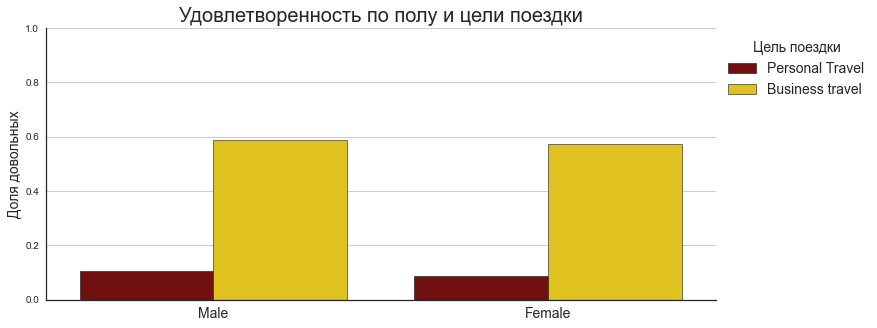

In [182]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Gender', y='satisfaction_0_1', 
            hue='Type of Travel', errorbar=None, edgecolor='black', linewidth=0.5, palette=['maroon', 'gold'])
plt.title('Удовлетворенность по полу и цели поездки', fontsize=20)
plt.ylabel('Доля довольных', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=14)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Цель поездки', title_fontsize=14, fontsize=14)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y')
plt.show()

**Интерпретация:** В деловых поездках доля довольных пассажиров значительно выше, чем в личных. Разница между мужчинами и женщинами незначительна.

# №12 Hex для скопления пассажиров по средней оценке сервиса и дальности полета

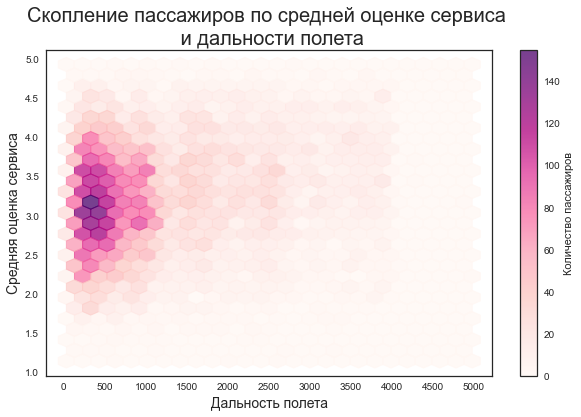

In [183]:
services = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
            'Gate location', 'Food and drink', 'Online boarding', 
            'Seat comfort', 'Inflight entertainment', 'On-board service', 
            'Leg room service', 'Baggage handling', 'Checkin service', 
            'Inflight service', 'Cleanliness'] 
df['avg_service'] = df[services].mean(axis=1)

plt.figure(figsize=(10, 6))
hb = plt.hexbin(df['Flight Distance'], df['avg_service'], gridsize=25, cmap='RdPu', alpha=0.75)
plt.colorbar(hb, label='Количество пассажиров')
plt.xticks([i for i in range(0, 5500, 500)])
plt.xlabel('Дальность полета', fontsize=14)
plt.ylabel('Средняя оценка сервиса', fontsize=14)
plt.title('Скопление пассажиров по средней оценке сервиса \n и дальности полета', fontsize=20)
plt.show()

**Интерпретация:** Основная масса пассажиров сконцентрирована на перелетах до 1000 км. Большинство оценок распределены от 2,3 до 4. Наибольшая плотность наблюдается при средней оценке сервиса 3,2.